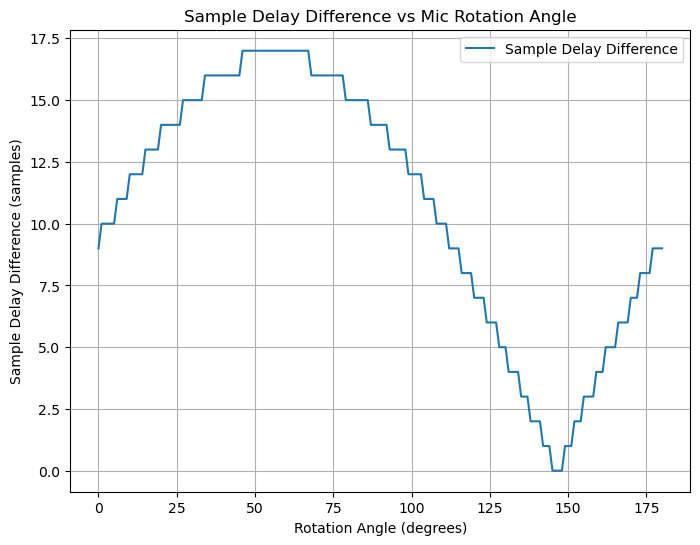

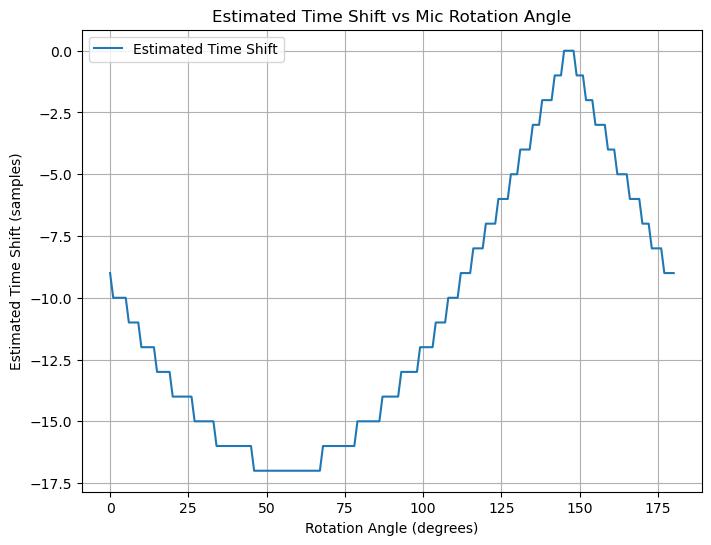

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram
from IPython.display import Audio
from scipy import signal
from scipy.fft import fft, ifft
from scipy.signal import correlate

# Microphone positions
mic1_initial = np.array([-0.06, 0])  # Mic 1 position
mic2_initial = np.array([0.06, 0])   # Mic 2 position
mic_distance = np.linalg.norm(mic2_initial - mic1_initial)  # Distance between microphones
midpoint = (mic1_initial + mic2_initial) / 2  # Midpoint between mics

# Sound source position
sound_source = np.array([2, 3])  # Bird call location

# Load the audio file
folder_path = r'Bird_sound'
filename = "Bird_call.wav"
file_path = os.path.join(folder_path, filename)
SR, z = wavfile.read(file_path)

# Play audio
Audio(z, rate=SR) 

# Normalise audio
z = z / np.max(np.abs(z))

# Function to rotate microphones around the origin
def mic_rotation(angle_to_rotate):
    angle_rad = np.radians(angle_to_rotate)
    rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                                 [np.sin(angle_rad), np.cos(angle_rad)]])
    mic1_rotated = np.dot(rotation_matrix, mic1_initial)
    mic2_rotated = np.dot(rotation_matrix, mic2_initial)
    return mic1_rotated, mic2_rotated

# Simulating microphone rotation
t_angles = []
sample_delay_differences = []
estimated_time_shifts = []

for i in range(0, 181, 1):  # Rotate from 0 to 180 degrees
    mic1_rotated, mic2_rotated = mic_rotation(i)
    
    # Compute theoretical time delay for rotated mics
    MicA_TimeDelay = np.linalg.norm(mic1_rotated - sound_source) / 343  # Speed of sound in m/s
    MicB_TimeDelay = np.linalg.norm(mic2_rotated - sound_source) / 343
    
    Total_TimeDelay = abs(MicA_TimeDelay - MicB_TimeDelay)
    Total_SampleDelay = round(Total_TimeDelay * SR)
    
    # Create shifted signals
    signal_A = z
    signal_B = np.roll(z, Total_SampleDelay)
    
    # FFT Calculation
    fft_A = fft(signal_A)
    fft_B = fft(signal_B)
    phase_A = np.angle(fft_A)
    phase_B = np.angle(fft_B)
    phase_diff = phase_B - phase_A
    
    # Cross-correlation to estimate time shift
    cross_corr = correlate(signal_A, signal_B)
    lags = np.arange(-len(signal_A) + 1, len(signal_A))
    time_shift = lags[np.argmax(cross_corr)]
    
    t_angles.append(i)
    sample_delay_differences.append(Total_SampleDelay)
    estimated_time_shifts.append(time_shift)

# Plot sample delay difference vs mic rotation angle
plt.figure(figsize=(8, 6))
plt.plot(t_angles, sample_delay_differences, label="Sample Delay Difference")
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Sample Delay Difference (samples)")
plt.title("Sample Delay Difference vs Mic Rotation Angle")
plt.grid(True)
plt.legend()
plt.show()

# Plot estimated time shift vs mic rotation angle
plt.figure(figsize=(8, 6))
plt.plot(t_angles, estimated_time_shifts, label="Estimated Time Shift")
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Estimated Time Shift (samples)")
plt.title("Estimated Time Shift vs Mic Rotation Angle")
plt.grid(True)
plt.legend()
plt.show()

